In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


In [2]:
# Load the dataset
wine_dataset = pd.read_csv('winequality-white.csv', sep = ';')
wine_dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [3]:
# Checking data types and null values
print(wine_dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


In [4]:
# Printing missing values
print(wine_dataset.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [5]:
# Remove dublicate rows
wine_dataset = wine_dataset.drop_duplicates()
print(wine_dataset.duplicated().sum()) # Checking no dublicates remain in dataset



0


In [6]:
# Print new shape of the dataset
print(wine_dataset.shape)

(3961, 12)


In [7]:
# Saving the cleaned dataset
wine_dataset.to_csv("cleaned_winequality_data.csv", index=False)
wine_dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [8]:
# summary statistics
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,6.839346,0.280538,0.334332,5.914819,0.045905,34.889169,137.193512,0.993790,3.195458,0.490351,10.589358,5.854835
std,0.866860,0.103437,0.122446,4.861646,0.023103,17.210021,43.129065,0.002905,0.151546,0.113523,1.217076,0.890683
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.600000,0.035000,23.000000,106.000000,0.991620,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,4.700000,0.042000,33.000000,133.000000,0.993500,3.180000,0.480000,10.400000,6.000000
75%,7.300000,0.330000,0.390000,8.900000,0.050000,45.000000,166.000000,0.995710,3.290000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [9]:
# Mean values grouped by quality
wine_dataset.groupby('quality').mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.600000,0.333250,0.336000,6.392500,0.054300,53.325000,170.600000,0.994884,3.187500,0.474500,10.345000
4,7.139869,0.382157,0.305229,4.499346,0.050059,23.127451,124.127451,0.994199,3.185425,0.476667,10.197712
5,6.921745,0.303306,0.335957,6.941532,0.052323,36.002979,150.099574,0.995072,3.171779,0.482621,9.864182
6,6.819435,0.261630,0.338227,5.959787,0.045178,35.308166,136.460850,0.993722,3.196029,0.492355,10.646122
7,6.701089,0.265363,0.327358,4.523875,0.037556,33.851234,122.052975,0.992059,3.228462,0.502859,11.515844
8,6.609924,0.286794,0.335038,5.056489,0.036756,35.618321,122.034351,0.991745,3.235115,0.485878,11.880153
9,7.420000,0.298000,0.386000,4.120000,0.027400,33.400000,116.000000,0.991460,3.308000,0.466000,12.180000


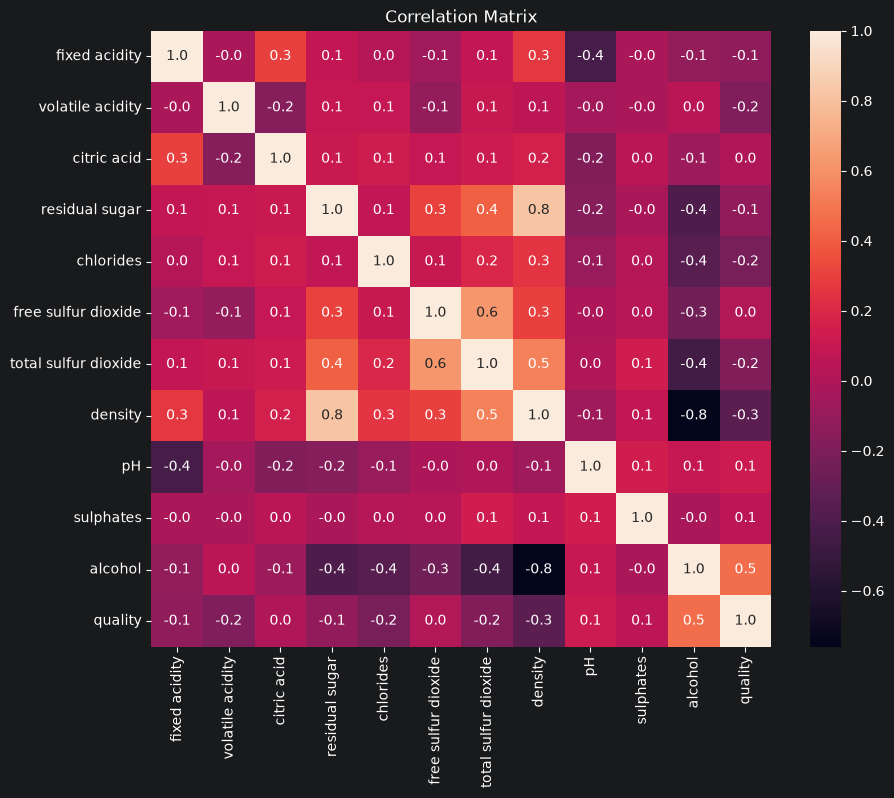

In [10]:
# Visualize correlations matrix
corr = wine_dataset.corr() # computing correlation matrix
 
plt.figure(figsize = (10, 8))
sns.heatmap(wine_dataset.corr(), annot=True, fmt= '.1f') # plotting correlation heatmap
plt.title('Correlation Matrix')
plt.show()

In [11]:
# Sorting the correlation values in decending order
corr['quality'].sort_values(ascending = False)

quality                 1.000000
alcohol                 0.462869
pH                      0.123829
sulphates               0.053200
free sulfur dioxide     0.010507
citric acid             0.007065
residual sugar         -0.117339
fixed acidity          -0.124636
total sulfur dioxide   -0.183356
volatile acidity       -0.190678
chlorides              -0.217739
density                -0.337805
Name: quality, dtype: float64

In [12]:
# Display the unique values in 'quality' column
wine_dataset['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [13]:
# create a copy of the dataset to ensure the original dataset remains unmodified
wine_dataset = wine_dataset.copy()

In [14]:
# Create a new column 'good quality' based on 'quality column
wine_dataset.loc[:, 'good quality'] = wine_dataset['quality'].apply(lambda x: 1 if x >= 6 else 0) # If the quality is 6 or greater, it is labeled as 'good qiality' (1), otherwise 'bad quality' (0) 
wine_dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1


In [15]:
# Showing how many wines are classified as (1) 'good quality' or (0) 'bad quality'
wine_dataset['good quality'].value_counts()

good quality
1    2613
0    1348
Name: count, dtype: int64

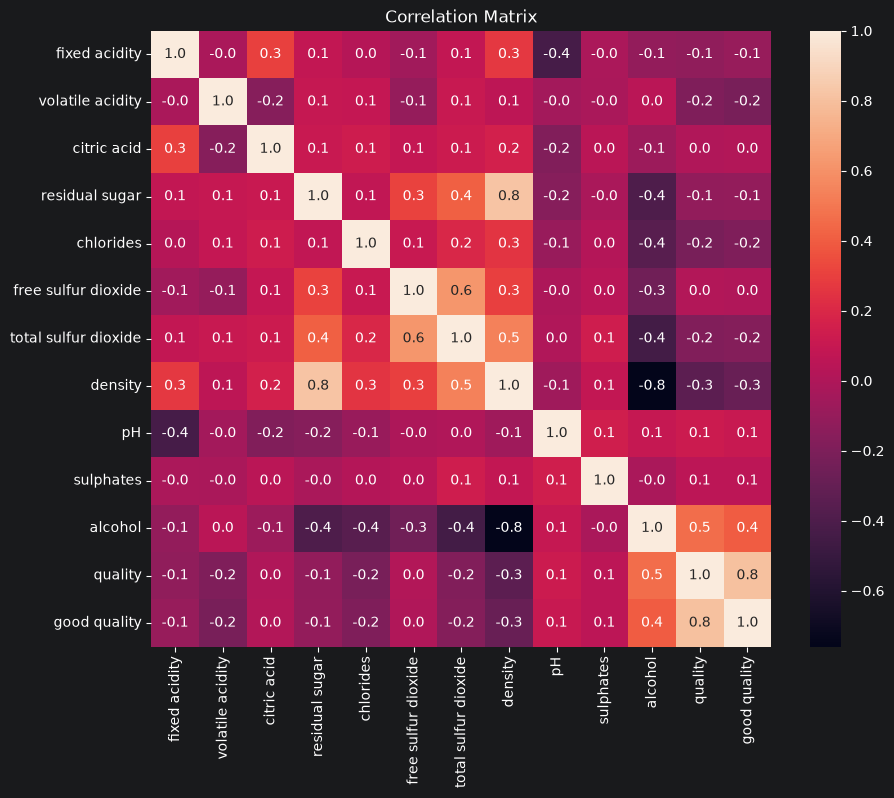

In [16]:
# Visualize correlation matrix
corr = wine_dataset.corr() # Compute correlation matrix
 
plt.figure(figsize = (10, 8))
sns.heatmap(wine_dataset.corr(), annot=True, fmt= '.1f') # Plotting correlation heatmap
plt.title('Correlation Matrix')
plt.show()

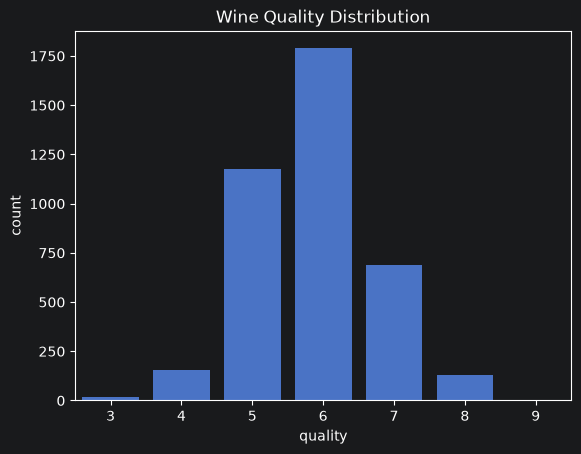

In [17]:
# Plotting distribution of quality 
sns.countplot(x ='quality', data = wine_dataset)
plt.title("Wine Quality Distribution")
plt.show()

In [18]:
# Prepareing the data for training
x = wine_dataset.drop(['quality','good quality'], axis = 1).values # Independent variables
y = wine_dataset['good quality'].values # Target variables

In [19]:
# Spliting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [20]:
# Printing the size of training data and testing data
print(f"Training set size: {x_train.shape}, Testing set size: {x_test.shape}")

Training set size: (2970, 11), Testing set size: (991, 11)


Decision Tree classification

In [21]:
# Training decision tree model 
modeltree = DecisionTreeClassifier(criterion= 'entropy', splitter= 'best',  max_depth = 4, random_state=42) 
modeltree.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
y_train_pred = modeltree.predict(x_train) # perdict for the train data
train_score = modeltree.score(x_train, y_train) #calculate the accuracy of train data
test_score = modeltree.score(x_test, y_test)    #calculate the accuracy of test data
# Print the training and testing accuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))


Training score: 0.76
Testing score: 0.74


In [23]:
# Predict the labels for test data using decision tree model
y_pred = modeltree.predict(x_test)
y_pred # Display the predicted labels for the test data

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [24]:
# Perform cross-validation
cv_scores = cross_val_score(modeltree, x_train, y_train, cv=5, scoring='accuracy')
# Print the mean and standard deviation of CV scores
print(f"Mean CV Score: {cv_scores.mean():.2f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.2f}")

Mean CV Score: 0.74
Standard Deviation of CV Scores: 0.01


In [25]:
# calculate the accuracy of the model on the test data
score = accuracy_score(y_test,y_pred)
# Print the accuracy score of the model
print(f'Accuracy Score: {score:.2f}')

Accuracy Score: 0.74


In [26]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.66      0.49      0.56       340
           1       0.76      0.87      0.81       651

    accuracy                           0.74       991
   macro avg       0.71      0.68      0.69       991
weighted avg       0.73      0.74      0.73       991



[[166 174]
 [ 87 564]]


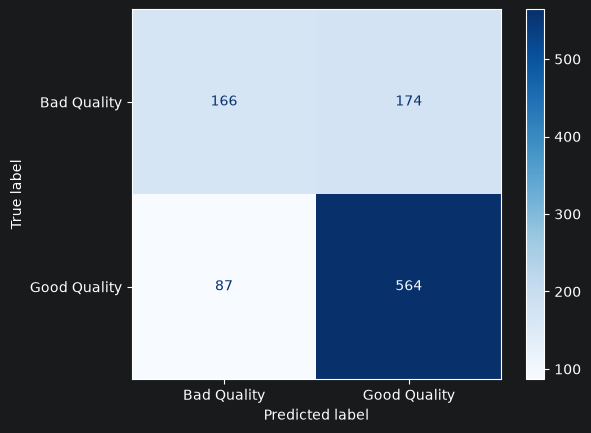

In [27]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot

Roc Auc score: 0.68


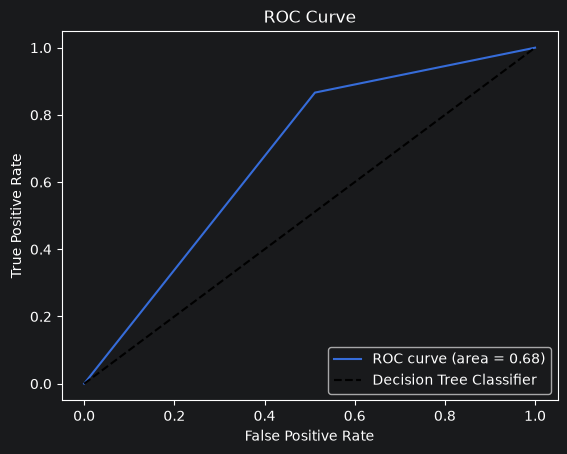

In [28]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred) 
# Print ROC AUC score
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='Decision Tree Classifier') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()

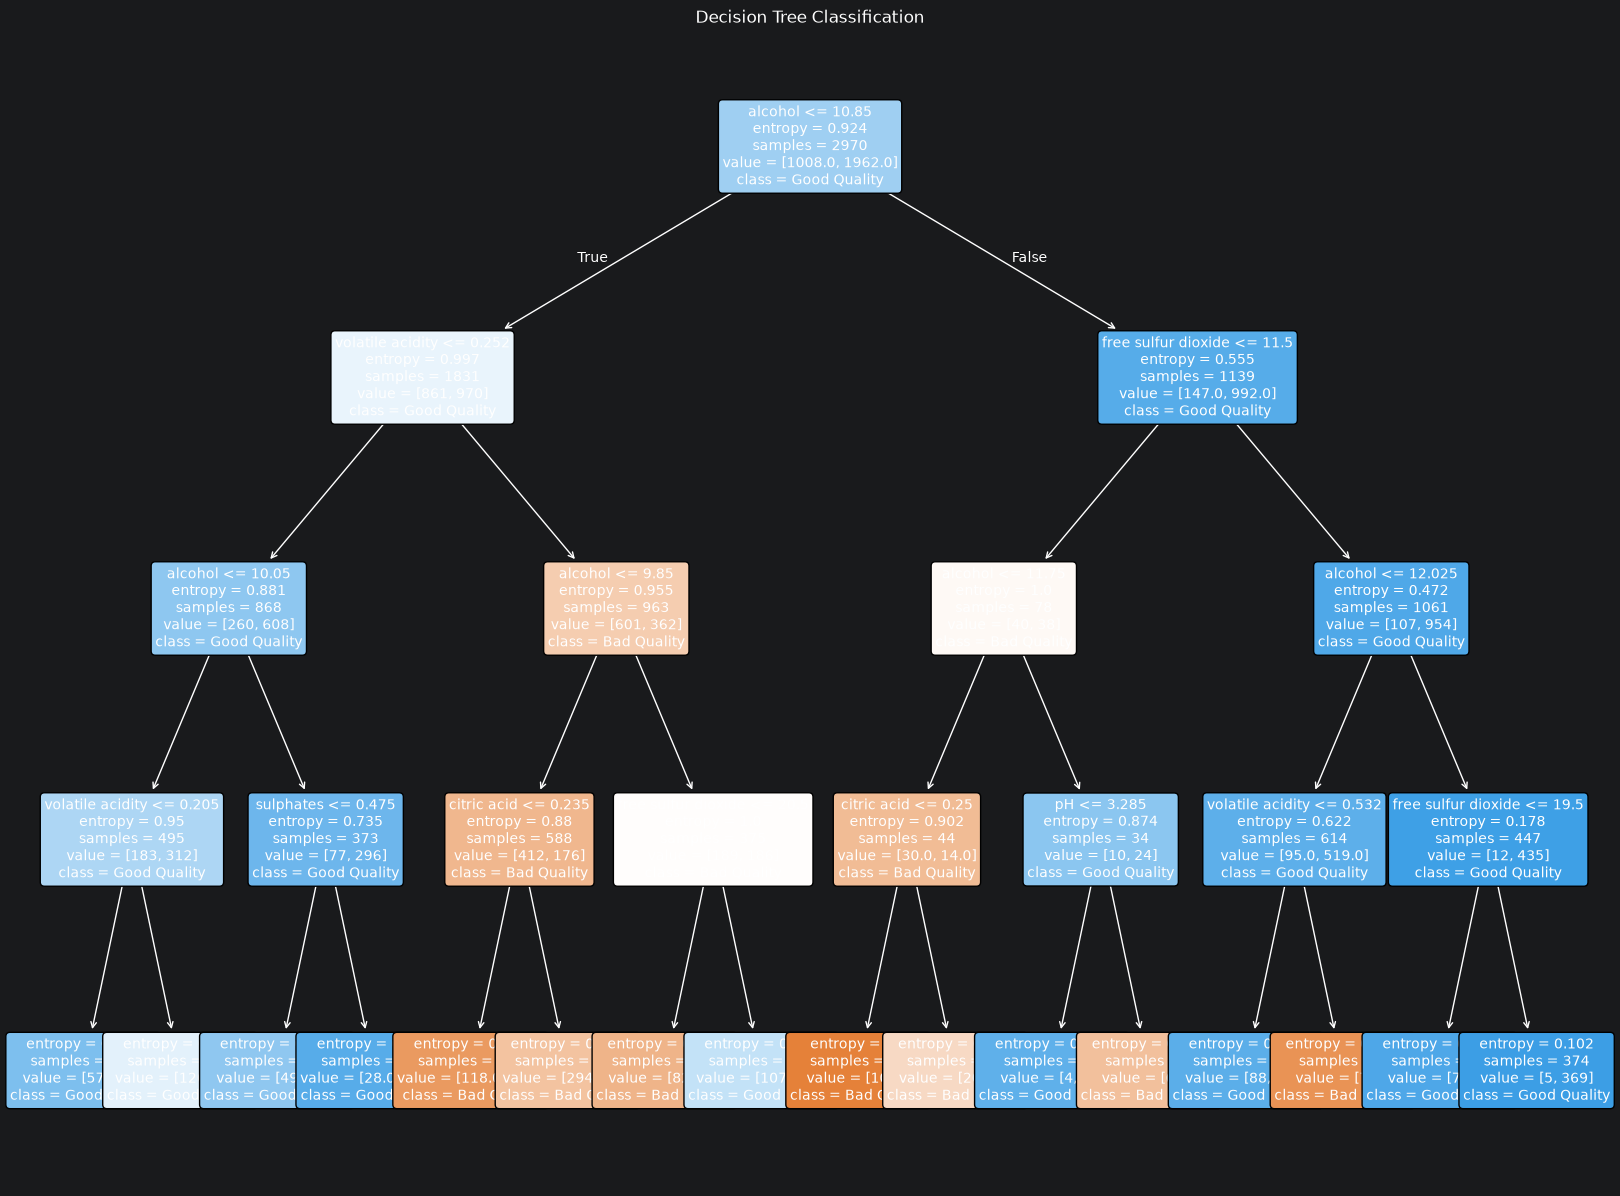

In [29]:
# Assign the trained decision tree model to a variable for visualization
best_tree = modeltree
# Plot the decision tree
plt.figure(figsize=(20, 15))
tree.plot_tree(best_tree, 
               feature_names=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                              'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
                              'pH', 'sulphates', 'alcohol'],  
               class_names=['Bad Quality', 'Good Quality'], 
               filled=True,
               rounded=True,
               fontsize=10)

plt.title("Decision Tree Classification")
plt.show()

In [30]:
# Define the hyperparameter grid for tuning the decision tree model
parameters = {
    'criterion': ['gini', 'entropy', 'log_loss'], # Different criteria for splitting nodes
    'splitter': ['best', 'random'], # Strategies for splitting at nodes
    'max_depth': [1,2,3,4,5,6,7], # Limits on tree depth for preventing overfitting
    'max_features': ['sqrt', 'log2'] # Number of features to consider at each split
}

In [31]:
# Initialize the decision tree classifier
treemodel = DecisionTreeClassifier(random_state=42)
# Using GridSearchCV to perform the hyperparameter tuning 
cv = GridSearchCV(treemodel, param_grid = parameters, cv = 5, scoring = 'accuracy')
# Fit the model
cv.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added

In [32]:
# Display the best Hyperparameters
cv.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [33]:
y_train_pred = cv.predict(x_train) # Perdict for training data
train_score = cv.score(x_train, y_train) #calculate the accuracy for the train data
test_score = cv.score(x_test, y_test)    #calculate the acuracy for the  test data
# Printing the training and testing accuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))

Training score: 0.79
Testing score: 0.73


In [34]:
# Predict the labels for test data using decision tree model
y_pred = cv.predict(x_test)
y_pred # Display the predicted labels for the test data

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,

In [35]:
# Perform cross-validation
cv_scores = cross_val_score(cv, x_train, y_train, cv=5, scoring='accuracy')
# Print the mean and standard deviation of CV scores
print(f"Decision Tree - Mean CV Score: {cv_scores.mean():.2f}")
print(f"Decision Tree - Standard Deviation of CV Scores: {cv_scores.std():.2f}")

Decision Tree - Mean CV Score: 0.72
Decision Tree - Standard Deviation of CV Scores: 0.01


In [36]:
# calculate the accuracy of the model on the test data
score = accuracy_score(y_test, y_pred)
# Print the accuracy score of the model
print(f'Accuracy Score: {score:.2f}')

Accuracy Score: 0.73


In [37]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.62      0.56      0.58       340
           1       0.78      0.82      0.80       651

    accuracy                           0.73       991
   macro avg       0.70      0.69      0.69       991
weighted avg       0.72      0.73      0.72       991



[[189 151]
 [118 533]]


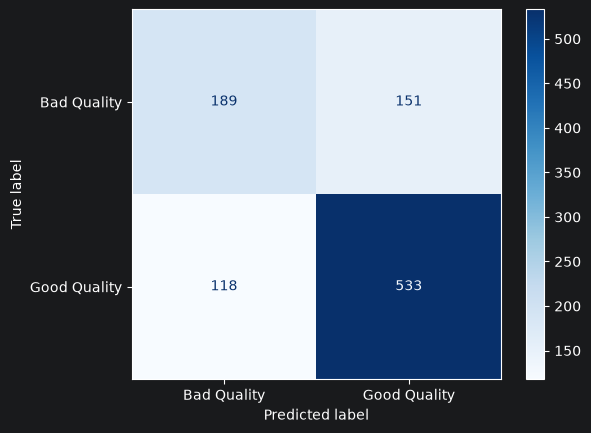

In [38]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot


Roc Auc score: 0.69


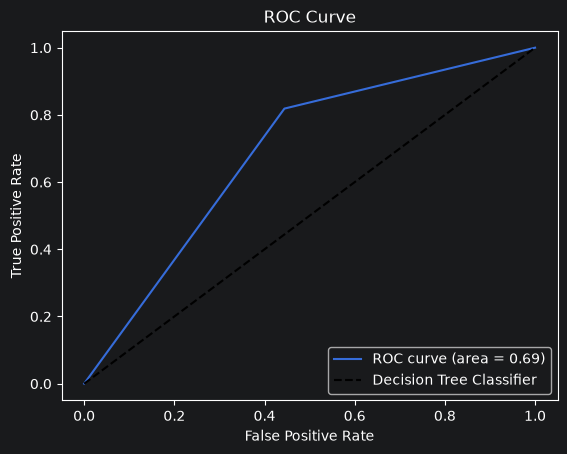

In [39]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred) 
# Print ROC AUC score
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='Decision Tree Classifier') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()

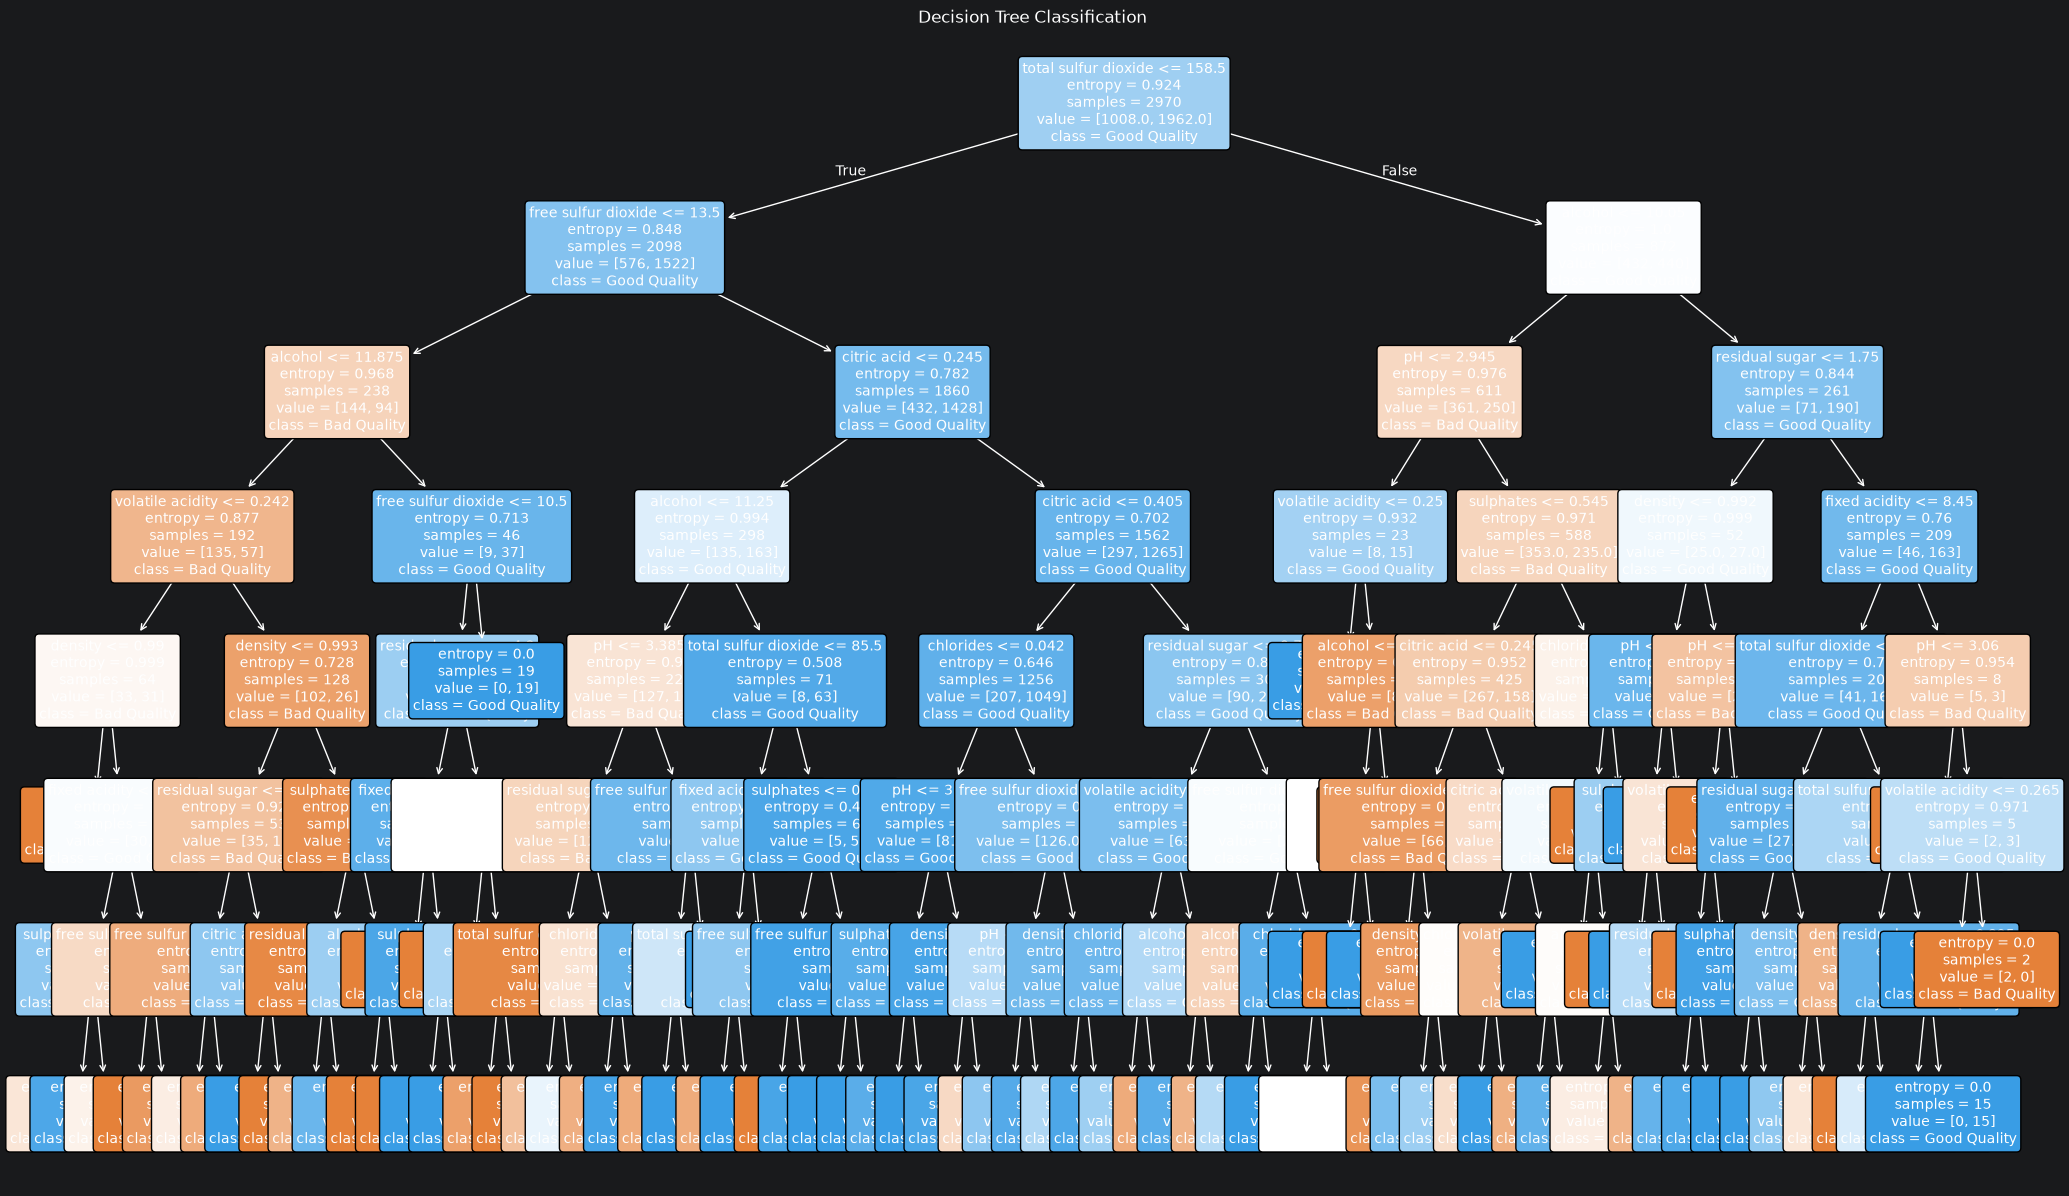

In [40]:
# Select the best model from the grid search results
best_tree = cv.best_estimator_
# Plot the decision tree
plt.figure(figsize=(25, 15))
tree.plot_tree(
    best_tree,
    feature_names=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
 'pH', 'sulphates', 'alcohol'],  
    class_names=['Bad Quality', 'Good Quality'], 
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classification")
plt.show()


Random Forest Classification

In [41]:
# Initialize and train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators= 100, max_features= 'log2', random_state = 42)
rf.fit(x_train, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [42]:
y_train_pred = rf.predict(x_train) # Predict for training data
train_score = rf.score(x_train, y_train) #calculate the accuracy for the train data
test_score = rf.score(x_test, y_test)    #calculate the accuracy for the test data
# Printing the trainig and testing accuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))

Training score: 1.00
Testing score: 0.77


In [43]:
# Predict the labels for test data using Random Forest model
y_pred = rf.predict(x_test)
y_pred # Display the predicted labels for the test data


array([1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,

In [44]:
# Perform cross-validation
cv_scores_rf = cross_val_score(rf, x_train, y_train, cv=5, scoring='accuracy')
# Print the mean and standard deviation of CV scores
print(f"Random Forest - Mean CV Score: {cv_scores_rf.mean():.2f}")
print(f"Random Forest - Standard Deviation of CV Scores: {cv_scores_rf.std():.2f}")

Random Forest - Mean CV Score: 0.78
Random Forest - Standard Deviation of CV Scores: 0.01


In [45]:
# calculate the accuracy of the model on the test data
score = (accuracy_score(y_test, y_pred))
# Print the accuracy score of the model
print(f'Accuracy Score: {score: .2f}')


Accuracy Score:  0.77


In [46]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.61      0.64       340
           1       0.81      0.85      0.83       651

    accuracy                           0.77       991
   macro avg       0.74      0.73      0.73       991
weighted avg       0.76      0.77      0.76       991



[[208 132]
 [100 551]]


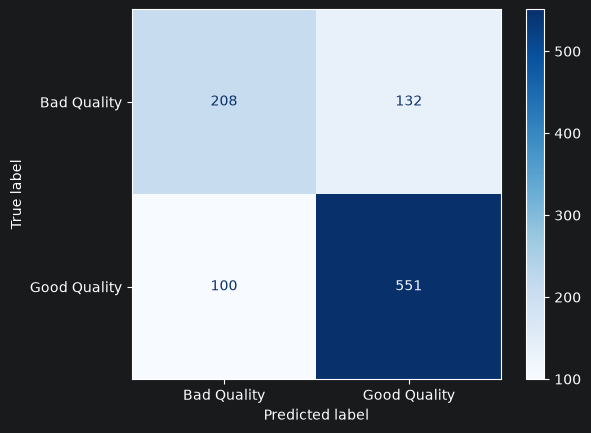

In [47]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm_rf = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot

Roc Auc score: 0.73


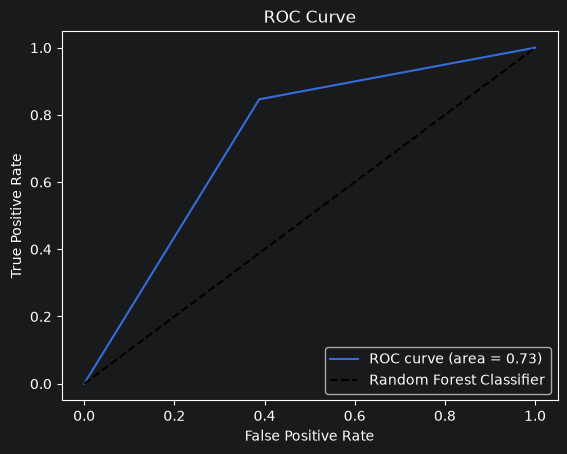

In [48]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred)
# Print ROC AUC score 
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='Random Forest Classifier') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()

In [49]:
# Define the hyperparameters to tune the Random Forrest Classifier
parameters = { 
    'n_estimators': [20,40,60,80,100,200], # The number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # The number of features to consider when looking for the best split
    'max_depth': [6,8,10,12,14,15,None], # The maximum depth of the trees
    'max_samples': [0.5,0.75,1.0], # The proportion of samples to use for training each tree
    'bootstrap': [True, False] # Whether bootstrap samples are used when building trees
} 

In [50]:
# Initialize the Random Forest Classifier 
rf = RandomForestClassifier()
# using gridSEarchCV for hyperparameter tuning the mdoel
rf_cv = GridSearchCV(estimator=rf, param_grid = parameters, cv=5, verbose=2, n_jobs=-1)
# Fit the model to the training data
rf_cv.fit(x_train, y_train)

Fitting 5 folds for each of 756 candidates, totalling 3780 fits
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=40; total time=   0.2s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=40; total time=   0.2s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, max_samples=0.5, n_estimators=40; total time=   0.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt,

KeyboardInterrupt: 

In [ ]:
# Display the best hyperparameters
rf_cv.best_params_

In [ ]:
y_train_pred = rf_cv.predict(x_train) # Predict the training data
train_score = rf_cv.score(x_train, y_train) #calculate the accuracy for the train data
test_score = rf_cv.score(x_test, y_test)    #calculate the accuracy for the test data
# Printing the training and testing accuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))

In [ ]:
# Predicty the labels for the test data using Random Forest model
y_pred = rf_cv.predict(x_test)
y_pred # Display the predicted labels for the test data

In [ ]:
# Perform cross-validation
cv_scores_rf = cross_val_score(rf_cv.best_estimator_, x_train, y_train, cv=5, scoring='accuracy')

# Print the mean and standard deviation of CV scores
print(f"Random Forest - Mean CV Score: {cv_scores_rf.mean():.2f}")
print(f"Random Forest - Standard Deviation of CV Scores: {cv_scores_rf.std():.2f}")

In [ ]:
# calculate the accuracy of the model on the test data
score = accuracy_score(y_test, y_pred)
# Print the accuracy score of the model
print(f'Accuracy Score: {score:.2f}')

In [ ]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

In [ ]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot

In [ ]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred) 
# Print ROC AUC score 
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='Random Forest Classifier') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()

In [ ]:
# plotting second decision tree in random forest.
rf_best = rf_cv.best_estimator_
tree_to_plot = rf_best.estimators_[1]
plt.figure(figsize=(30,25))
tree.plot_tree(tree_to_plot, filled = True)
plt.show()

Support Vector Machine

In [ ]:
# Create an instance of StandardScaler to standarize the features
sc = StandardScaler()
# Fit the scaler of the training data and transform it
x_train_sc = sc.fit_transform(x_train)
# Use the scaler to transform the test data
x_test_sc = sc.transform(x_test)

In [ ]:
# Create an instance of the SVC
svc = SVC(C = 1, kernel = 'rbf', gamma = 0.2)
# Fit the SVC mocel to the standardized training data and corresponding y_train 
svc.fit(x_train_sc, y_train)

In [ ]:
y_train_pred = svc.predict(x_train) # perdict for trainig data
train_score = svc.score(x_train_sc, y_train) #calculate the accuracy for the train data
test_score = svc.score(x_test_sc, y_test)    #calculate the accuracy for the test data
# Printing the training and testing sccuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))

In [ ]:
# Predict the labels for test data using SVC model
y_pred = svc.predict(x_test_sc)
y_pred # Display the predicted labels for the test data

In [ ]:
# Perform cross-validation
cv_scores_svm = cross_val_score(svc, x_train_sc, y_train, cv=5, scoring='accuracy')

# Print the mean and standard deviation of CV scores
print(f"SVC - Mean CV Score: {cv_scores_svm.mean():.2f}")
print(f"SVC - Standard Deviation of CV Scores: {cv_scores_svm.std():.2f}")

In [ ]:
# Calculate decision function
decision_scores = svc.decision_function(x_test_sc)
print("Decision Scores:", decision_scores)

In [ ]:
# calculate the accuracy of the model on the test data
score = accuracy_score(y_test, y_pred)
# Print the accuracy score of the model
print(f'Accuracy Score: {score:.2f}')

In [ ]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

In [ ]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot

In [ ]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred)
# Print ROC AUC score
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='SVC') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()

In [ ]:
# Define the hyperparameters to tune for the Support Vector Classifier (SVC)
parameters = {
    'C': [0.1, 0.2, 0.5, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4],
    'kernel': ['rbf', 'linear']
}

In [ ]:
# Initialize a SVC model
svc = SVC()
svc_cv = GridSearchCV(estimator=svc, param_grid = parameters, cv=5, verbose=2, n_jobs=-1)
# Fit the model on the training data to find ther best hyperparameters
svc_cv.fit(x_train_sc, y_train) 

In [ ]:
# Display the best hyperparameters
svc_cv.best_params_

In [ ]:
y_train_pred = svc_cv.predict(x_train_sc) # Predict the training data
train_score = svc_cv.score(x_train_sc, y_train) #calculate the accuracy for the train data
test_score = svc_cv.score(x_test_sc, y_test)    #calculate the accuracy for the test data
# Printing the training and testing accuracy scores
print("Training score: {:.2f}".format(train_score))
print("Testing score: {:.2f}".format(test_score))

In [ ]:
# Predict the labels for the test data using SVC
y_pred = svc_cv.predict(x_test_sc)
y_pred # Dispaly the predicted labels for the test data

In [ ]:
# Perform cross-validation
cv_scores_svm = cross_val_score(svc_cv.best_estimator_, x_train_sc, y_train, cv=5, scoring='accuracy')

# Print the mean and standard deviation of CV scores
print(f"SVC - Mean CV Score: {cv_scores_svm.mean():.2f}")
print(f"SVC - Standard Deviation of CV Scores: {cv_scores_svm.std():.2f}")

In [ ]:
# calculate the accuracy of the model on the test data
score = accuracy_score(y_test, y_pred)
# Print the accuracy score of the model
print(f'Accuracy Score: {score:.2f}')

In [ ]:
# Print the heading for the  classification report
print(f'Classification Report: ')
# generate and print classification report
print(classification_report(y_test,y_pred))

In [ ]:
# Calculate the confusion matrix to evaluate the performance of the classification
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))
# display the confusion matrix using ConfusionMatrixDisplay for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Quality", "Good Quality"])
# Plot the confusion matrix with 'Blues' colormap
disp.plot(cmap='Blues')
plt.show() # Display the plot

In [ ]:
# Calculate the the ROC AUC score to evalute the models ability
roc_auc = roc_auc_score(y_test, y_pred) 
# Print ROC AUC score 
print(f'Roc Auc score: {roc_auc:.2f}')
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
# Plot the ROC curve 
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc) 
# roc curve for tpr = fpr  
plt.plot([0, 1], [0, 1], 'k--', label='SVC') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve') 
plt.legend(loc="lower right") 
plt.show()